In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import LeaveOneOut
import numpy as np
import pdb
from imblearn.over_sampling import SMOTE
#from catboost import CatBoostClassifier
#from imblearn.combine import SMOTEENN  # ✅ Import SMOTEENN
from collections import Counter
print("okay")

okay


In [2]:
pwd 'Waves data Individual Trajectories-modified.xlsx'

'c:\\Users\\Muhammad Aqib\\Desktop\\ASD experiments'

In [2]:

# Load the Excel file
#file_path = "/kaggle/input/asd-and-control-modified/Waves data Individual Trajectories-modified.xlsx"
# file_path = '\\Users\\Muhammad Aqib\\Desktop\\ASD experiments\\Waves data Individual Trajectories-modified.xlsx'
file_path = '/home/tanvirdell3/Downloads/ASDvsControl/Waves data Individual Trajectories-modified.xlsx'

In [3]:
# test
asd_data = pd.read_excel(file_path, sheet_name="ASD", skiprows=1, nrows=237)
control_data = pd.read_excel(file_path, sheet_name="Control", skiprows=1, nrows=237)
asd_data.columns = asd_data.columns.map(str)
control_data.columns = control_data.columns.map(str)

In [4]:
asd_data = pd.read_excel(file_path, sheet_name="ASD", skiprows=0, nrows=237)
control_data = pd.read_excel(file_path, sheet_name="Control", skiprows=0, nrows=237)

In [7]:
asd_data.head()

,a9,a9.1,a9.2,a9.3,a9.4,a9.5,a9.6,a9.7,a9.8,a9.9,...,GA039.10,GA039a.10,GA039.11,GA039.12,a,GA039.13,GA039a.11,GA039.14,GA039a.12,GA039.15
0,1.204,0.799,1.114,-0.119,0.602,0.114,-0.367,0.398,0.949,1.204,...,1.114,1.114,0.799,0.602,0.602,0.949,0.949,-0.119,-0.119,0.398000
1,uV,uV,uV,uV,uV,uV,uV,uV,uV,uV,...,uV,uV,uV,uV,uV,uV,uV,uV,uV,-1.451156
2,0.559658,0.19251,-1.932362,0.553445,1.308576,-0.299054,0.886285,0.804946,-0.057604,0.084359,...,-0.539017,-0.458826,-0.011485,-0.458494,-0.344236,0.859969,0.730124,-0.124611,0.912734,-1.405032
3,0.541656,0.16781,-1.843291,0.515173,1.256268,-0.282047,0.85987,0.735639,-0.064046,0.085545,...,-0.577956,-0.541377,-0.042635,-0.478574,-0.342108,0.819289,0.695424,-0.143917,0.857609,-1.355873
4,0.520374,0.145697,-1.753148,0.471246,1.205094,-0.259426,0.83153,0.670849,-0.068788,0.087754,...,-0.592241,-0.606126,-0.066722,-0.49246,-0.335919,0.779519,0.663297,-0.147496,0.7966,-1.303679


In [12]:
asd_data.shape

(237, 1025)

In [6]:
# Drop all columns starting with "Unnamed"
asd_data = asd_data.loc[:, ~asd_data.columns.str.startswith('Unnamed')]
control_data = control_data.loc[:, ~control_data.columns.str.startswith('Unnamed')]
print('*')

*


In [17]:
### for all record , each record as a sample
selected_asd = asd_data.drop(index=[0, 1]).reset_index(drop=True)
selected_control = control_data.drop(index=[0, 1]).reset_index(drop=True)

In [24]:
selected_control.shape, selected_asd.shape

((235, 1563), (235, 1025))

In [12]:
# for single record check
columns_to_keep = [col for col in asd_data.columns if col.startswith('a9')]
new_df_asd = asd_data[columns_to_keep]

# Select columns where first row value is exactly 1.114
selected_columns_asd = new_df_asd.columns[new_df_asd.iloc[0] == 1.114]
selected_asd = asd_data[selected_columns_asd]

# Drop first two rows and reset index
selected_asd = selected_asd.drop(index=[0, 1]).reset_index(drop=True)

# Take mean across selected columns and save into new 'a9' column
selected_asd['a9'] = selected_asd.mean(axis=1)

# Keep only 'a9' column (✅ no comma mistake)
selected_asd = selected_asd[['a9']]

# Show
selected_asd.head()


,a9
0,-0.451497
1,-0.435712
2,-0.418064
3,-0.398552
4,-0.377178


In [6]:
# filter out asd data using particular flash strength
# Your list of main group names
group_columns = [
    'a10', 'a100', 'a20', 'a21', 'a22', 'a23b', 'a25', 'a27', 'a28', 'a29',
    'a3', 'a31', 'a33', 'a34', 'a36', 'a37', 'a43', 'a46', 'a47', 'a48',
    'a5', 'a52', 'A60', 'a61', 'a7', 'a', 'a9', 'GA002b', 'GA003b', 'GA006','GA006a','GA006b','GA006c'
    'GA008', 'GA010', 'GA012', 'GA014', 'GA017', 'GA018', 'GA019', 'GA023',
    'GA027', 'GA028', 'GA029', 'GA030', 'GA031', 'GA037', 'GA038', 'GA039'
]

# Create empty DataFrame to collect results
final_df_asd = pd.DataFrame()

for group in group_columns:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in asd_data.columns if col.split('.')[0] == group]
    
    if not matching_cols:
        
        continue  # Skip if no matching columns found
    
    # 2. Create sub-dataframe
    temp_df = asd_data[matching_cols]
    
    # 3. Select columns where first row == 1.204
    selected_cols = temp_df.columns[temp_df.iloc[0] == 1.204]
    
    if selected_cols.empty:
        #pdb.set_trace()
        continue  # Skip if no columns satisfy first row == 1.204

    # 4. Keep only selected columns
    selected_data = temp_df[selected_cols]
    
    # 5. Drop first two rows and reset index
    selected_data = selected_data.drop(index=[0, 1]).reset_index(drop=True)

    # 6. Take mean across selected columns
    final_df_asd[group] = selected_data.mean(axis=1)

# Done! Final_df has one column per group
final_df_asd.head()


,a10,a100,a20,a21,a22,a23b,a25,a27,a28,a29,...,GA019,GA023,GA027,GA028,GA029,GA030,GA031,GA037,GA038,GA039
0,-0.701794,-0.242332,0.228823,0.172721,0.547538,0.18357,1.16949,-2.232023,1.971904,0.785506,...,0.461241,-0.335965,0.148935,1.055458,-0.410659,-0.198144,-0.245588,-0.230905,-0.446659,0.583468
1,-0.692507,-0.219302,0.241359,0.178323,0.497013,0.179021,1.041226,-2.073735,1.896722,0.761954,...,0.45369,-0.335996,0.157582,1.060561,-0.229175,-0.202628,-0.241078,-0.221677,-0.435737,0.559252
2,-0.678822,-0.202176,0.233315,0.173984,0.452176,0.173586,0.922335,-1.92054,1.81871,0.729481,...,0.438625,-0.333638,0.15171,1.038474,-0.088346,-0.206747,-0.238495,-0.212962,-0.420428,0.539625
3,-0.660736,-0.190956,0.204692,0.159704,0.413027,0.167265,0.812815,-1.77244,1.73787,0.688085,...,0.416049,-0.328893,0.131318,0.989196,0.011827,-0.210502,-0.23784,-0.20476,-0.40073,0.524588
4,-0.638252,-0.18564,0.155488,0.135484,0.379566,0.16006,0.712669,-1.629434,1.6542,0.637769,...,0.385959,-0.321759,0.096407,0.912727,0.071346,-0.213892,-0.239112,-0.197071,-0.376643,0.514141


In [7]:
# filter out control data using particular flash strength
# Your list of main group names
group_columns_c = [
    'C009', 'C010', 'C011b', 'C013', 'C015', 'C016', 'C017', 'C018', 'C019',
    'C020', 'C021', 'C024', 'C025', 'C028', 'C029', 'C031', 'C032', 'C035',
    'C036', 'C039', 'C041', 'C047', 'C049', 'C050', 'c1', 'c10', 'c105', 'c14',
    'c2', 'c4', 'c40', 'c400', 'c41', 'c42', 'c44', 'c45', 'c5', 'c50', 'c52',
    'c53', 'c55', 'c56', 'c6', 'c60', 'c61', 'c64', 'c65', 'c66', 'c67', 'c68',
    'c7', 'c71', 'c77', 'c78', 'c8', 'c80', 'c81', 'c83', 'c84', 'c9'
]

# Create empty DataFrame to collect results
final_df_control = pd.DataFrame()

for group in group_columns_c:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in control_data.columns if col.split('.')[0] == group]
    
    if not matching_cols:
        continue  # Skip if no matching columns found
    
    # 2. Create sub-dataframe
    temp_df = control_data[matching_cols]
    
    # 3. Select columns where first row == 1.204
    selected_cols = temp_df.columns[temp_df.iloc[0] == 1.204]
    
    if selected_cols.empty:
        continue  # Skip if no columns satisfy first row == 1.204

    # 4. Keep only selected columns
    selected_data = temp_df[selected_cols]
    
    # 5. Drop first two rows and reset index
    selected_data = selected_data.drop(index=[0, 1]).reset_index(drop=True)

    # 6. Take mean across selected columns
    final_df_control[group] = selected_data.mean(axis=1)

# Done! Final_df has one column per group
final_df_control.head()


,C009,C010,C011b,C013,C015,C016,C017,C018,C019,C020,...,c7,c71,c77,c78,c8,c80,c81,c83,c84,c9
0,-0.121084,-0.483748,0.032166,-0.199353,-0.453065,0.293358,0.230984,-0.170401,-0.357424,-0.365836,...,0.241273,0.633128,0.336511,-0.357249,0.081282,-0.489903,0.470239,0.638698,0.099679,-0.488796
1,-0.086946,-0.443093,0.015144,-0.192568,-0.417562,0.310983,0.189574,-0.161821,-0.321661,-0.349436,...,0.231446,0.595368,0.296356,-0.330978,0.115203,-0.429968,0.439522,0.467343,0.120188,-0.497903
2,-0.05402,-0.39832,-0.002094,-0.185178,-0.382488,0.329412,0.16403,-0.143616,-0.286546,-0.325049,...,0.220582,0.547877,0.259918,-0.304844,0.152475,-0.374246,0.409249,0.328645,0.128949,-0.504029
3,-0.022304,-0.349427,-0.019549,-0.177184,-0.347843,0.348646,0.154352,-0.115786,-0.252081,-0.292673,...,0.20868,0.490654,0.227197,-0.278846,0.193098,-0.322737,0.37942,0.222603,0.12596,-0.507174
4,0.008201,-0.296416,-0.037221,-0.168586,-0.313627,0.368685,0.16054,-0.078332,-0.218264,-0.252309,...,0.195741,0.423698,0.198193,-0.252985,0.237073,-0.275442,0.350036,0.149219,0.111222,-0.507337


In [ ]:
# without mean
# Extract all columns starting with '0.602' from asd sheet

columns_to_keep = [col for col in asd_data.columns if col.startswith('0.602')]
new_df_asd = asd_data[columns_to_keep]
print(new_df_asd.head())

# Extract all columns starting with '0.602' from control sheet
columns_to_keep = [col for col in control_data.columns if col.startswith('0.602')]
new_df_control = control_data[columns_to_keep]

print(new_df_control.head())

In [8]:
final_df_asd.shape, final_df_control.shape

((235, 45), (235, 60))

In [ ]:
## drop first row for first case
new_df_asd = new_df_asd.drop(index=0).reset_index(drop=True)
new_df_control = new_df_control.drop(index=0).reset_index(drop=True)

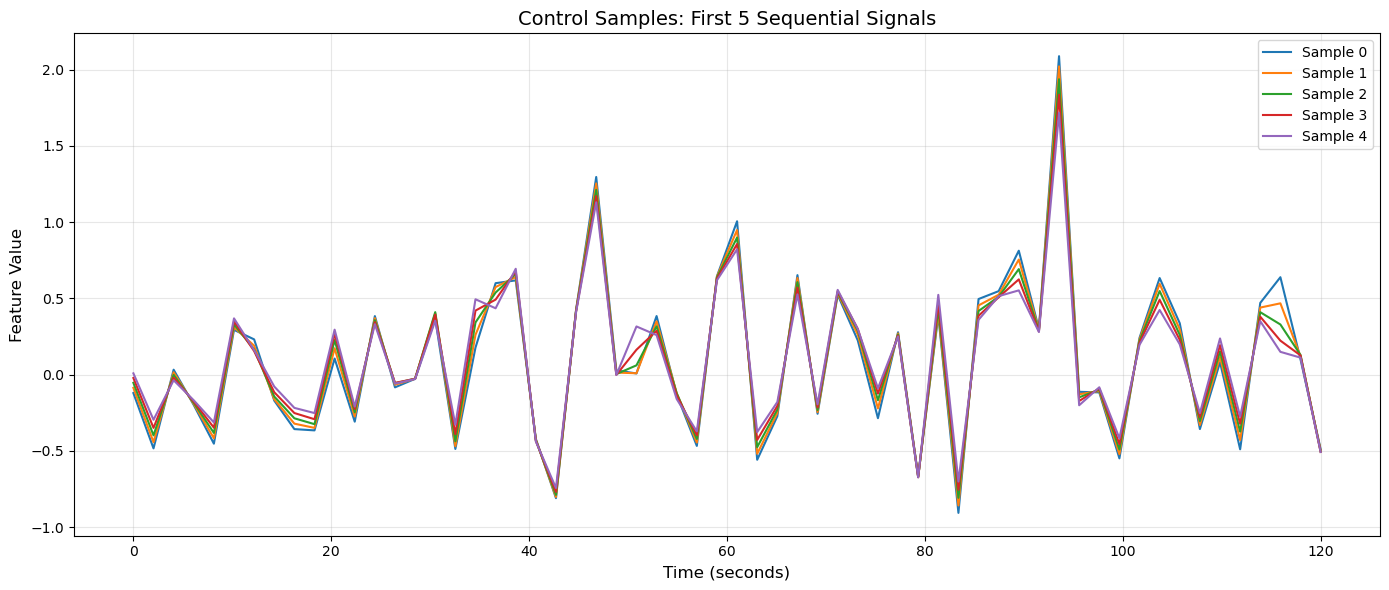

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Create time axis from 0 to 120 sec with 235 steps
time_axis = np.linspace(0, 120, final_df_control.shape[1])

# Plot first 5 samples
for i in range(min(5, final_df_control.shape[0])):
    plt.plot(time_axis, final_df_control.iloc[i], label=f'Sample {i}', linewidth=1.5)

# Customize plot
plt.title("Control Samples: First 5 Sequential Signals", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Feature Value", fontsize=12)
plt.xticks(np.arange(0, 121, 20))  # X-axis ticks: 0, 20, ..., 120
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


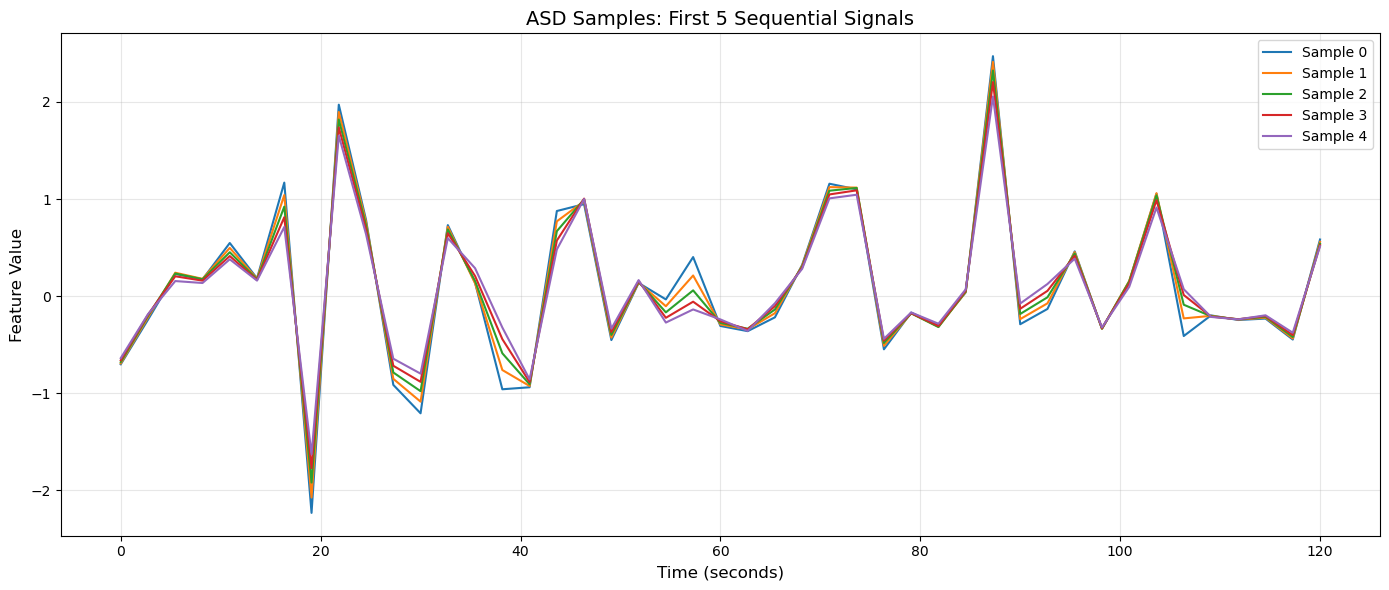

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Create time axis from 0 to 120 sec with 235 steps
time_axis = np.linspace(0, 120, final_df_asd.shape[1])

# Plot first 5 samples
for i in range(min(5, final_df_asd.shape[0])):
    plt.plot(time_axis, final_df_asd.iloc[i], label=f'Sample {i}', linewidth=1.5)

# Customize plot
plt.title("ASD Samples: First 5 Sequential Signals", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Feature Value", fontsize=12)
plt.xticks(np.arange(0, 121, 20))  # X-axis ticks: 0, 20, ..., 120
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
filtered_asd_df = final_df_asd.T  
filtered_control_df = final_df_control.T 
print('*')

*


In [10]:
asd_reshaped = filtered_asd_df.reset_index(drop=True)
control_reshaped = filtered_control_df.reset_index(drop=True)
print('*')

*


In [11]:
n_features = asd_reshaped.shape[1]
asd_reshaped.columns = [f'F{i}' for i in range(n_features)]
control_reshaped.columns = [f'F{i}' for i in range(n_features)]
print('*')

*


In [12]:
asd_reshaped.shape, control_reshaped.shape

((45, 235), (60, 235))

In [13]:
control_reshaped.head()

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F225,F226,F227,F228,F229,F230,F231,F232,F233,F234
0,-0.121084,-0.086946,-0.05402,-0.022304,0.008201,0.038076,0.067345,0.096007,0.124062,0.155036,...,-11.483306,-11.467099,-11.462359,-11.469085,-11.491334,-11.469821,-11.404541,-11.295496,-11.173689,-11.08982
1,-0.483748,-0.443093,-0.39832,-0.349427,-0.296416,-0.239286,-0.177823,-0.112029,-0.041902,0.032557,...,-16.355092,-16.510844,-16.646067,-16.760755,-16.85491,-16.896405,-16.885236,-16.821407,-16.704919,-16.622741
2,0.032166,0.015144,-0.002094,-0.019549,-0.037221,-0.055109,-0.07373,-0.093084,-0.113171,-0.133991,...,-2.220383,-2.171515,-2.143407,-2.136059,-2.14947,-2.155865,-2.155243,-2.147606,-2.132953,-2.127227
3,-0.199353,-0.192568,-0.185178,-0.177184,-0.168586,-0.159385,-0.151601,-0.145236,-0.14029,-0.136762,...,-7.443229,-7.266442,-7.077707,-6.877027,-6.664399,-6.417956,-6.137697,-5.823623,-5.475734,-5.229315
4,-0.453065,-0.417562,-0.382488,-0.347843,-0.313627,-0.279751,-0.246199,-0.212971,-0.180066,-0.147995,...,-5.666391,-6.075929,-6.457121,-6.809965,-7.138667,-7.464241,-7.786684,-8.105997,-8.426789,-8.6951


# SMOTE

In [ ]:
# Step 1: Combine ASD and Control data
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control


# Step 2: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 3: Convert to DataFrame if needed
X_resampled_df = pd.DataFrame(X_resampled)
y_resampled_df = pd.Series(y_resampled)

# Optional: Check new class distribution
from collections import Counter
print("New class distribution:", Counter(y_resampled))

X_resampled_df.shape, y_resampled_df.shape
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_resampled_df)
y = y_resampled_df
print('*')


New class distribution: Counter({np.int64(1): 60, np.int64(0): 60})


# SMOTE for all record, each record one samsple base case 1 experiment

In [22]:
selected_asd.shape, selected_control.shape

((235, 1025), (235, 1563))

In [25]:
filtered_asd_df = selected_asd.T  
filtered_control_df = selected_control.T 
print('*')

*


In [26]:
asd_reshaped = filtered_asd_df.reset_index(drop=True)
control_reshaped = filtered_control_df.reset_index(drop=True)
print('*')

*


In [27]:
n_features = asd_reshaped.shape[1]
asd_reshaped.columns = [f'F{i}' for i in range(n_features)]
control_reshaped.columns = [f'F{i}' for i in range(n_features)]
print('*')

*


In [30]:
asd_reshaped.head()

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F225,F226,F227,F228,F229,F230,F231,F232,F233,F234
0,0.559658,0.541656,0.520374,0.495813,0.467972,0.436852,0.390512,0.328953,0.252176,0.16018,...,-18.506245,-18.002562,-17.680453,-17.539909,-17.58094,-17.568775,-17.503415,-17.38486,-17.213113,-17.221893
1,0.19251,0.16781,0.145697,0.126171,0.109234,0.094884,0.083839,0.076099,0.071664,0.070533,...,-15.679538,-15.066753,-14.657438,-14.451591,-14.449212,-14.657563,-15.076637,-15.706439,-16.546965,-17.325719
2,-1.932362,-1.843291,-1.753148,-1.661933,-1.569648,-1.476292,-1.381864,-1.286364,-1.189792,-1.092149,...,-1.770119,-1.943599,-2.094427,-2.222604,-2.32813,-2.593201,-3.017818,-3.601982,-4.345691,-4.958932
3,0.553445,0.515173,0.471246,0.421665,0.366428,0.30531,0.23831,0.165429,0.086666,0.017638,...,-5.770532,-5.735663,-5.725189,-5.739111,-5.77534,-5.833878,-5.914723,-6.017876,-6.113953,-6.202952
4,1.308576,1.256268,1.205094,1.155051,1.106142,1.058365,1.011663,0.966038,0.921488,0.878015,...,-14.176872,-14.063531,-14.023419,-14.056532,-14.162875,-14.298977,-14.464837,-14.660456,-14.885836,-15.125253


In [38]:
# Step 1: Combine ASD and Control data
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control


# Step 2: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 3: Convert to DataFrame if needed
X_resampled_df = pd.DataFrame(X_resampled)
y_resampled_df = pd.Series(y_resampled)

# Optional: Check new class distribution
from collections import Counter
print("New class distribution:", Counter(y_resampled))

X_resampled_df.shape, y_resampled_df.shape
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_resampled_df)
y = y_resampled_df
print('*')


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
X_resampled_df.shape, y_resampled_df.shape
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_resampled_df)
y = y_resampled_df
print('*')

*


# Save dataframe after SMOTE

In [16]:
X_resampled_df.shape, y_resampled_df.shape

((120, 235), (120,))

In [37]:
X_resampled_df['label'] = y_resampled_df.values
X_resampled_df.to_csv("resampled_final_data.csv", index=False)

# Without SMOTE

In [32]:
asd_reshaped['Label'] = 1
control_reshaped['Label'] = 0

# Step 4: Combine
combined_df = pd.concat([asd_reshaped, control_reshaped], ignore_index=True)
#combined_df = combined_df.fillna(0)
# Step 5: Split features and labels
X = combined_df.drop(columns=['Label'])
y = combined_df['Label']

# Step 6: Normalize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.preprocessing import PowerTransformer


# Combine ASD and Control data (original, real data)
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

# Scale data (MinMax for all)
scaler = MinMaxScaler()
X_scaled_mm = scaler.fit_transform(X)

scaler = StandardScaler()
X_scaled_ss = scaler.fit_transform(X)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)


# Create feature column names (e.g., F0, F1, ..., Fn)
feature_columns_mm = [f'F{i}' for i in range(X_scaled_mm.shape[1])]
feature_columns_ss = [f'F{i}' for i in range(X_scaled_ss.shape[1])]

# Create the DataFrame
df_mm = pd.DataFrame(X_scaled_mm, columns=feature_columns_mm)
df_ss = pd.DataFrame(X_scaled_ss, columns=feature_columns_ss)

df_power = pd.DataFrame(X_transformed, columns=feature_columns_mm)
# Add the label column
df_mm['Label'] = y
df_ss['Label'] = y

df_power['Label'] = y

# Show the first few rows
df_mm.shape, df_ss.shape, df_power.shape



((2588, 237), (2588, 237), (2588, 237))

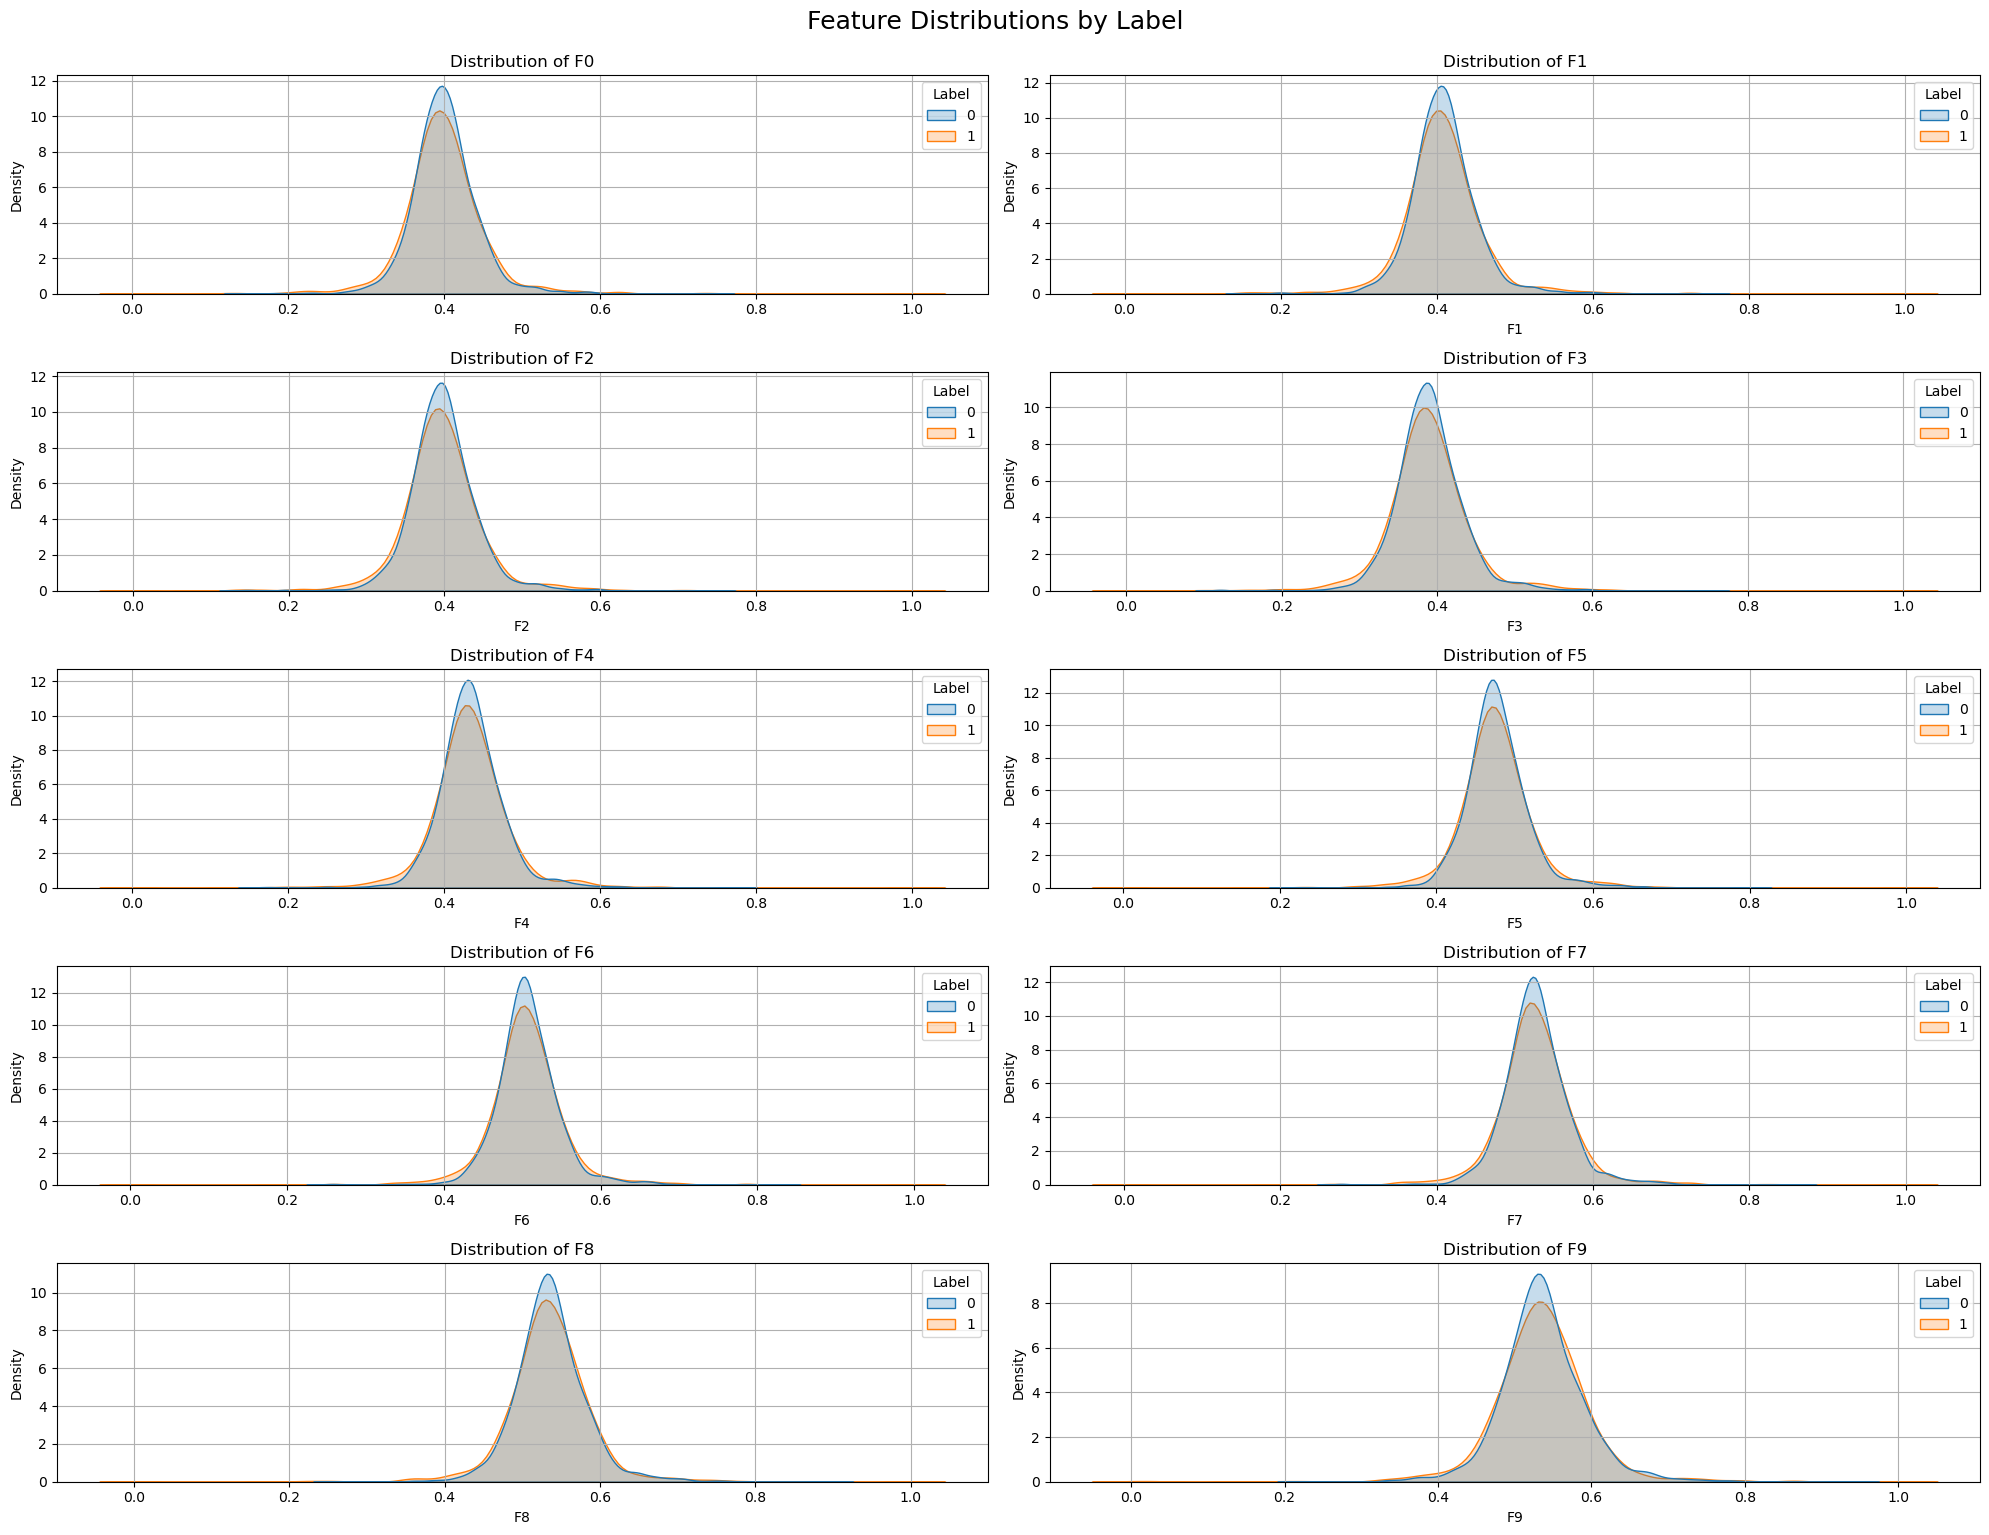

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
df_plot = df_mm
# Ensure numeric conversion
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

# Select only numeric columns
numeric_cols = df_plot.select_dtypes(include=['number'])

# Plot the first N numeric features (change N as needed)
N = 10
features_to_plot = numeric_cols.columns[:N]  # ✅ Correct way to get first N columns

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(5, 2, i)
    sns.kdeplot(data=df_plot, x=feature, hue="Label", common_norm=False, fill=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Feature Distributions by Label", fontsize=18, y=1.02)
plt.show()


# Train/ Test Split

In [35]:
# Step 7: Train/test split
X_train, X_test, y_train, y_test = train_test_split(df_mm, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2070, 237), (518, 237), (2070,), (518,))


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       318
           1       1.00      1.00      1.00       200

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Sensitivity (Recall): 1.0000
Specificity: 1.0000
AUC Score: 1.0000


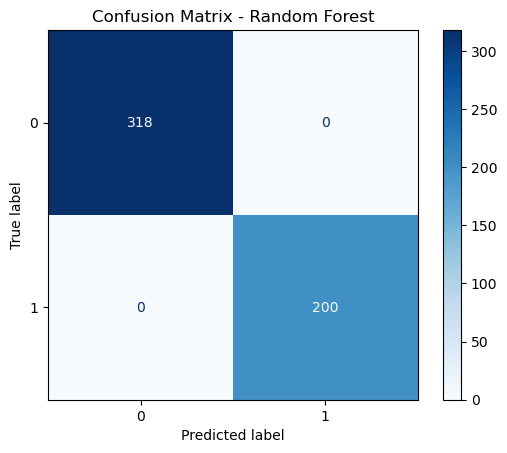

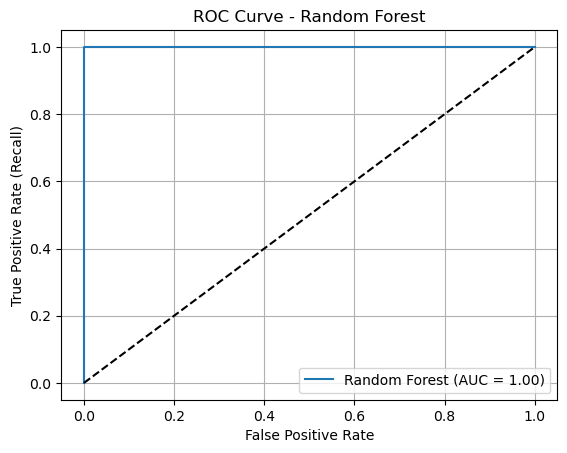


=== AdaBoost ===


ValueError: Input X contains NaN.
AdaBoostClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [36]:
# Step 8: Define classifiers
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
}
# Step 9: Evaluation
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_test, probas)

    # Classification Report
    print(classification_report(y_test, predictions))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, probas)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [37]:
# Step 8: Define classifiers
models = {
    "SVM": SVC(probability=True)
}
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Handle models that may not support predict_proba
    if hasattr(model, "predict_proba"):
        probas = model.predict_proba(X_test)[:, 1]
    else:
        # Use decision_function and normalize it between 0-1 as an approximation
        decision_scores = model.decision_function(X_test)
        probas = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_test, probas)

    # Classification Report
    print(classification_report(y_test, predictions))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, probas)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



=== SVM ===


ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.model_selection import GridSearchCV

models = {
    "SVM": SVC(probability=True)
}

# Define SVM hyperparameter grid
param_grid = {
    'C': [50],
    'kernel': ['rbf', 'poly'],
    'gamma': [0.01],
    'degree': [3]  # Only relevant for 'poly' kernel
}

for name, base_model in models.items():
    print(f"\n=== {name} with Hyperparameter Tuning ===")

    # Step 1: Create GridSearchCV for SVM
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        verbose=2,
        n_jobs=-1
    )

    # Step 2: Fit the grid search
    grid_search.fit(X_train, y_train)

    # Step 3: Get the best model
    model = grid_search.best_estimator_

    # Step 4: Predictions
    predictions = model.predict(X_test)

    # Handle models that may not support predict_proba
    if hasattr(model, "predict_proba"):
        probas = model.predict_proba(X_test)[:, 1]
    else:
        decision_scores = model.decision_function(X_test)
        probas = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_test, probas)

    # Classification Report
    print("\nBest Parameters:", grid_search.best_params_)
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, probas)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


# MLP

In [ ]:
from fastai.tabular.all import *
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Prepare dataset
df = pd.DataFrame(X, columns=[f'F{i}' for i in range(X.shape[1])])
df['Label'] = y.values
df['Label'] = df['Label'].astype('category')

# Step 2: Create DataLoaders
dls = TabularDataLoaders.from_df(
    df,
    y_names='Label',
    cat_names=[],
    cont_names=[f'F{i}' for i in range(X.shape[1])],
    valid_pct=0.2,
    seed=42,
    bs=64
)

# Step 3: Create a deeper MLP learner
learn = tabular_learner(
    dls,
    layers=[512, 256, 128],    # Deeper MLP (optimized)
    metrics=[accuracy, RocAucBinary()],
    loss_func=CrossEntropyLossFlat()
)

# Step 4: Find best learning rate
learn.lr_find()
# Pick a good learning rate from the plot manually (example: 1e-2)

# Step 5: Train
learn.fit_one_cycle(20, lr_max=1e-2)  # Train for 20 epochs

# Step 6: Predictions
preds, targs = learn.get_preds()
pred_labels = preds.argmax(dim=1)

# Step 7: Confusion matrix
cm = confusion_matrix(targs, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Step 8: ROC Curve
probs = preds[:,1]  # Probability for positive class
fpr, tpr, thresholds = roc_curve(targs, probs)
auc_score = roc_auc_score(targs, probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Step 9: Calculate evaluation metrics
precision = precision_score(targs, pred_labels)
recall = recall_score(targs, pred_labels)
f1 = f1_score(targs, pred_labels)
accuracy = accuracy_score(targs, pred_labels)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# Step 10: Print final table
print("\nFinal Evaluation Results:\n")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC Score    : {auc_score:.4f}")


# Leave One Out CV


=== Random Forest (LOOCV) ===
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        60
           1       0.88      0.97      0.92        60

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120

Sensitivity (Recall): 0.9667
Specificity: 0.8667
AUC Score: 0.9687


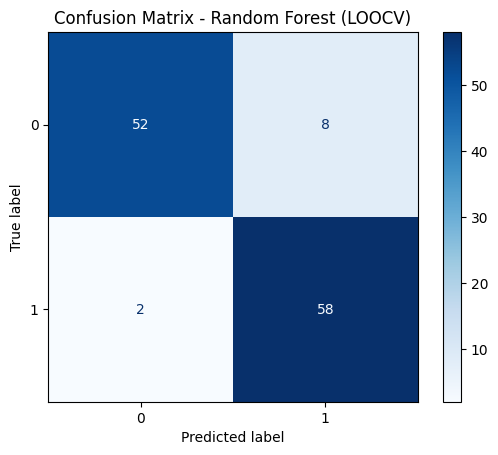

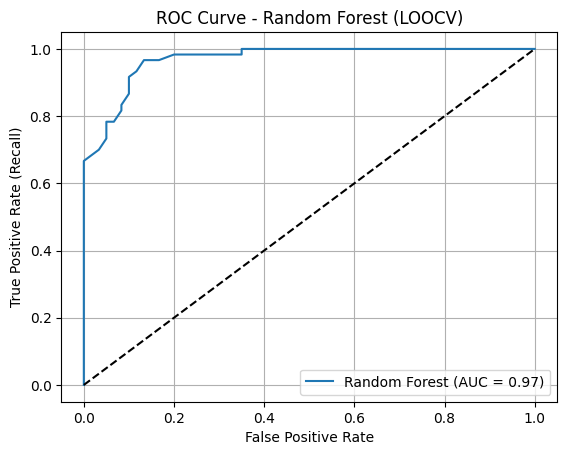


=== AdaBoost (LOOCV) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Sensitivity (Recall): 1.0000
Specificity: 1.0000
AUC Score: 1.0000


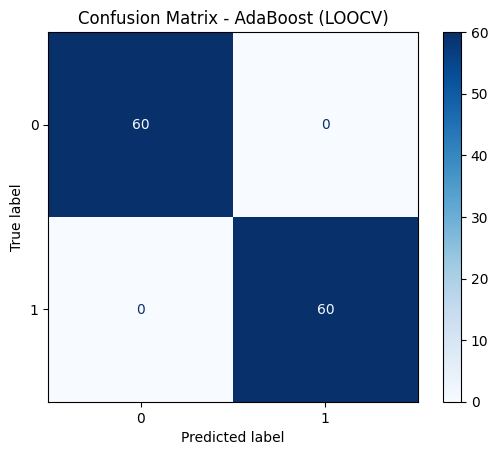

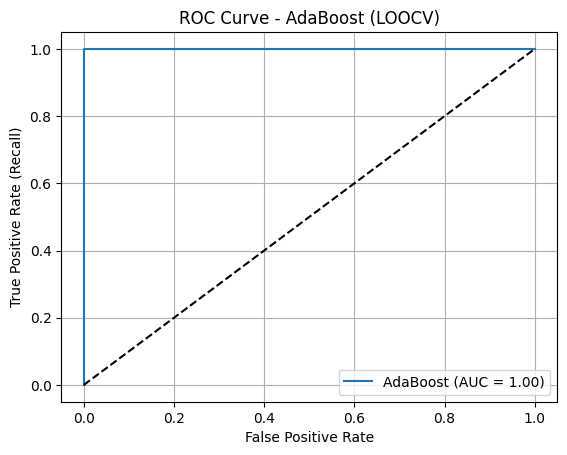


=== Gradient Boosting (LOOCV) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Sensitivity (Recall): 1.0000
Specificity: 1.0000
AUC Score: 1.0000


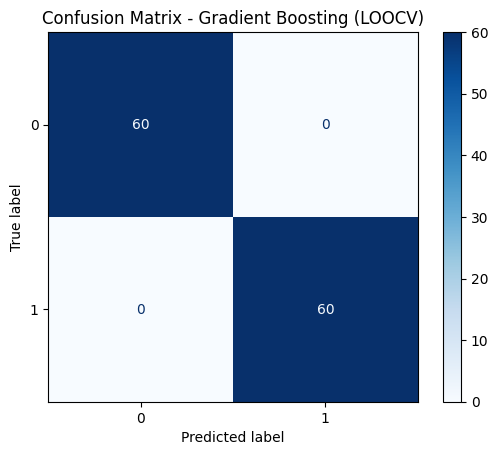

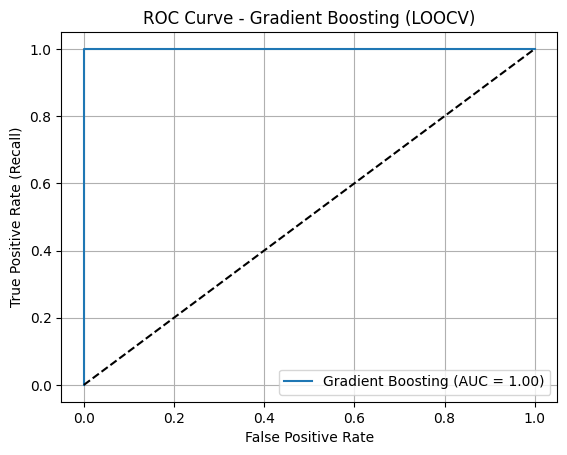


=== XGBoost (LOOCV) ===


c:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:47:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarni

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Sensitivity (Recall): 1.0000
Specificity: 1.0000
AUC Score: 1.0000


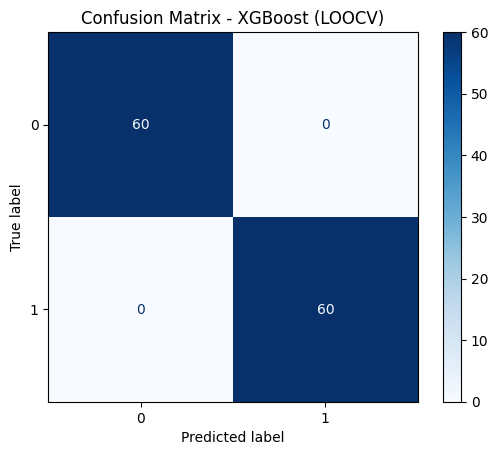

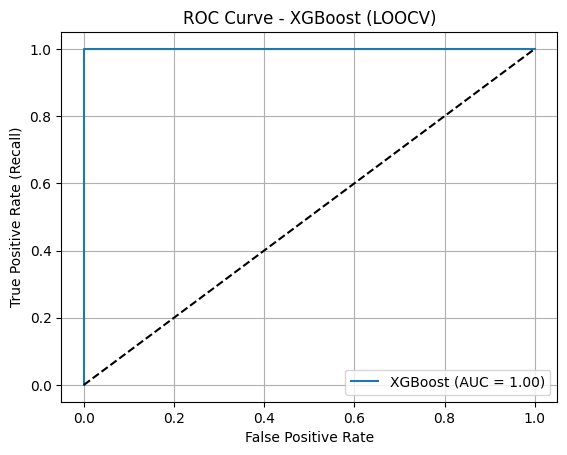


=== KNN (LOOCV) ===
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        60
           1       0.92      0.80      0.86        60

    accuracy                           0.87       120
   macro avg       0.87      0.87      0.87       120
weighted avg       0.87      0.87      0.87       120

Sensitivity (Recall): 0.8000
Specificity: 0.9333
AUC Score: 0.9332


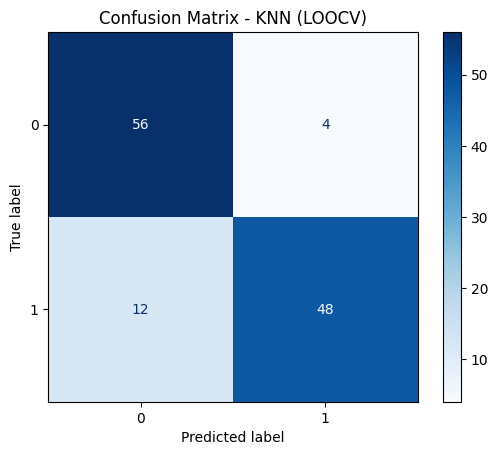

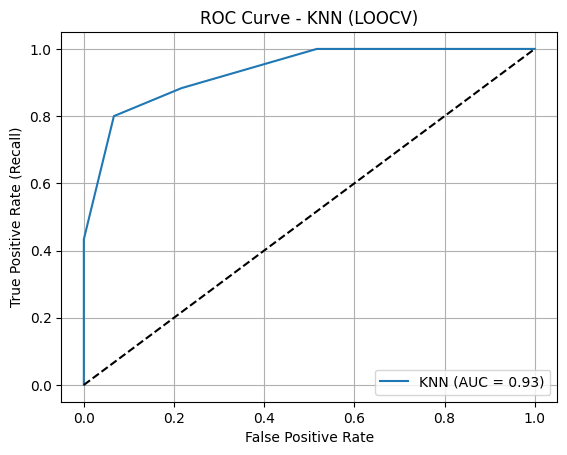

In [40]:
# Step 7: Define Leave-One-Out cross-validator
loo = LeaveOneOut()

# Step 8: Define classifiers
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
    #"CatBoost": CatBoostClassifier(verbose=0)  # ✅ Add CatBoost here
}

# Step 9: Evaluation with LOOCV
for name, model in models.items():
    print(f"\n=== {name} (LOOCV) ===")

    y_true = []
    y_pred = []
    y_proba = []

    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

        y_true.append(y_test.values[0])  # Because y_test is a 1-row DataFrame
        y_pred.append(pred[0])
        y_proba.append(prob[0])

    # After LOOCV ends
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_true, y_proba)

    # Classification Report
    print(classification_report(y_true, y_pred))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (LOOCV)")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name} (LOOCV)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



=== SVM (LOOCV) ===
              precision    recall  f1-score   support

           0       0.60      0.83      0.70        60
           1       0.55      0.27      0.36        45

    accuracy                           0.59       105
   macro avg       0.57      0.55      0.53       105
weighted avg       0.58      0.59      0.55       105

Sensitivity (Recall): 0.2667
Specificity: 0.8333
AUC Score: 0.5289


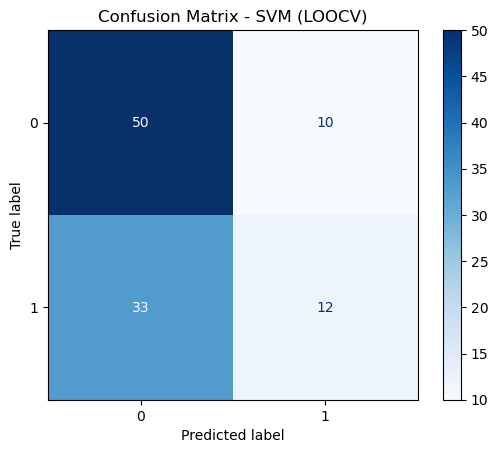

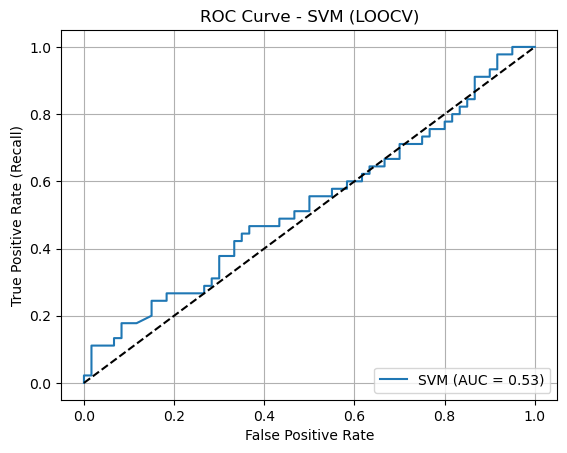

In [23]:
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# Step 7: Define Leave-One-Out cross-validator
loo = LeaveOneOut()

# Step 8: Define classifier
models = {
    "SVM": SVC(probability=True)
}

# Step 9: Evaluation with LOOCV
for name, base_model in models.items():
    print(f"\n=== {name} (LOOCV) ===")

    y_true = []
    y_pred = []
    y_proba = []

    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = base_model
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        # Handle models that may not support predict_proba
        if hasattr(model, "predict_proba"):
            probas = model.predict_proba(X_test)[:, 1]
        else:
            decision_scores = model.decision_function(X_test)
            probas = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

        y_true.append(y_test.values[0])    # Single value
        y_pred.append(predictions[0])
        y_proba.append(probas[0])

    # Convert lists to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_true, y_proba)

    # Classification Report
    print(classification_report(y_true, y_pred))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (LOOCV)")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name} (LOOCV)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


=== SVM with Hyperparameter Tuning (LOOCV) ===

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.78      0.69        60
           1       0.55      0.36      0.43        45

    accuracy                           0.60       105
   macro avg       0.59      0.57      0.56       105
weighted avg       0.59      0.60      0.58       105

Sensitivity (Recall): 0.3556
Specificity: 0.7833
AUC Score: 0.6185


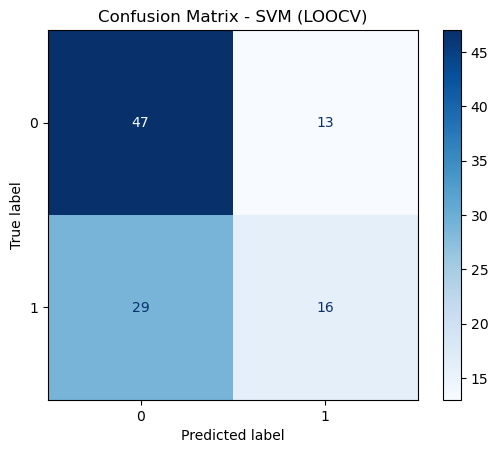

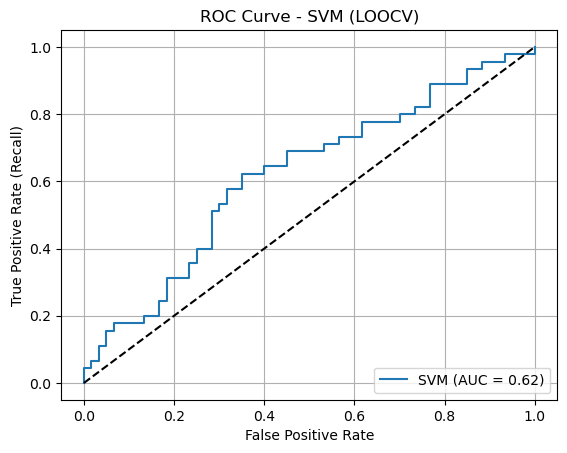

In [24]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# Step 7: Leave-One-Out cross-validator
loo = LeaveOneOut()

# Step 8: Define model
models = {
    "SVM": SVC(probability=True)
}

# Step 9: Define hyperparameter grid
param_grid = {
    'C': [100],
    'gamma': [0.01, 0.1],
    'kernel': ['poly', 'rbf'],
    'degree':[3,4,5]
}

# Step 10: Evaluation with LOOCV + GridSearchCV
for name, base_model in models.items():
    print(f"\n=== {name} with Hyperparameter Tuning (LOOCV) ===")

    y_true = []
    y_pred = []
    y_proba = []

    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Grid Search within this fold
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            scoring='accuracy',
            cv=5,
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)

        # Best model for this fold
        model = grid_search.best_estimator_

        # Prediction
        prediction = model.predict(X_test)

        # Probabilities
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)[:, 1]
        else:
            decision_scores = model.decision_function(X_test)
            proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

        y_true.append(y_test.values[0])
        y_pred.append(prediction[0])
        y_proba.append(proba[0])

    # Convert lists to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # AUC Score
    auc = roc_auc_score(y_true, y_proba)

    # Final report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (LOOCV)")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name} (LOOCV)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


# Fast Ai

In [27]:
from fastai.tabular.all import *
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut

# Step 1: Prepare dataset
df = pd.DataFrame(X_scaled, columns=[f'F{i}' for i in range(X.shape[1])])
df['Label'] = y.values
df['Label'] = df['Label'].astype('category')

# Step 2: Setup LOOCV
loo = LeaveOneOut()

# Collect all predictions and true labels
all_preds = []
all_probs = []
all_targets = []

for train_idx, test_idx in loo.split(df):
    # Split manually
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Create DataLoaders
    dls = TabularDataLoaders.from_df(
        train_df,
        y_names='Label',
        cat_names=[],
        cont_names=[f'F{i}' for i in range(X.shape[1])],
        valid_idx=None,  # No validation set needed here
        bs=64
    )

    # Create learner
    learn = tabular_learner(
        dls,
        layers=[512, 256, 128],
        metrics=[accuracy],  # ✅ Only accuracy (NO RocAucBinary here)
        loss_func=CrossEntropyLossFlat()
    )

    # Train model (fewer epochs for speed)
    learn.fit_one_cycle(10, lr_max=1e-2)

    # Predict on the left-out test sample
    test_dl = learn.dls.test_dl(test_df)
    preds, targs = learn.get_preds(dl=test_dl)

    # Store results
    all_preds.append(preds.argmax(dim=1).item())
    all_probs.append(preds[:,1].item())
    all_targets.append(targs.item())

# Convert to numpy arrays
y_true = np.array(all_targets)
y_pred = np.array(all_preds)
y_proba = np.array(all_probs)

# Step 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (LOOCV - MLP FastAI)")
plt.show()

# Step 4: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc_score = roc_auc_score(y_true, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (LOOCV - MLP FastAI)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Step 5: Evaluation Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# Step 6: Print final results
print("\nFinal Evaluation Results (LOOCV):\n")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC Score    : {auc_score:.4f}")


ModuleNotFoundError: No module named 'fastai'

In [26]:
pip uninstall fastai

Note: you may need to restart the kernel to use updated packages.


# Fast Ai updated parameters

In [ ]:
from fastai.tabular.all import *
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut

# Step 1: Prepare dataset
df = pd.DataFrame(X_scaled, columns=[f'F{i}' for i in range(X_scaled.shape[1])])
df['Label'] = y.values
df['Label'] = df['Label'].astype('category')

# Step 2: Setup LOOCV
loo = LeaveOneOut()

# Collect all predictions and true labels
all_preds = []
all_probs = []
all_targets = []

for train_idx, test_idx in loo.split(df):
    # Split manually
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Create DataLoaders
    dls = TabularDataLoaders.from_df(
        train_df,
        y_names='Label',
        cat_names=[],  # No categorical features
        cont_names=[f'F{i}' for i in range(X_scaled.shape[1])],
        valid_idx=None,
        bs=8  # small batch size
    )

    # Create model using TabularModel class
    model = TabularModel(
        emb_szs=[],  # No embedding sizes
        n_cont=X_scaled.shape[1],
        out_sz=2,     # binary classification
        layers=[128, 64],
        ps=[0.3, 0.3]  # dropout after each layer
    )

    # Create Learner manually
    learn = Learner(
        dls,
        model,
        loss_func=CrossEntropyLossFlat(),
        metrics=[accuracy],
        wd=1e-2
    )

    # Train model
    learn.fit_one_cycle(15, lr_max=1e-3)

    # Predict on the left-out test sample
    test_dl = learn.dls.test_dl(test_df)
    preds, targs = learn.get_preds(dl=test_dl)

    # Store results
    all_preds.append(preds.argmax(dim=1).item())
    all_probs.append(preds[:,1].item())
    all_targets.append(targs.item())

# Step 3: Convert to numpy arrays
y_true = np.array(all_targets)
y_pred = np.array(all_preds)
y_proba = np.array(all_probs)

# Step 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Optimized MLP FastAI - LOOCV)")
plt.show()

# Step 5: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc_score = roc_auc_score(y_true, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Optimized MLP FastAI - LOOCV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Step 6: Evaluation Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# Step 7: Print final results
print("\nFinal Evaluation Results (LOOCV Optimized):\n")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC Score    : {auc_score:.4f}")


# LSTM

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, classification_report
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.random import set_seed
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Set seed for reproducibility
set_seed(42)

# Step 1: Prepare LSTM-compatible input
# Assuming X_resampled and y_resampled are your SMOTE balanced datasets
# X_resampled = X_scaled
# y_resampled = y.values
X_lstm = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)  # shape: (samples, timesteps, features)
y_lstm = y_resampled


# Step 2: Setup LOOCV
loo = LeaveOneOut()
y_true, y_pred, y_proba = [], [], []

print("\n=== Bidirectional LSTM (LOOCV) ===")

for train_idx, test_idx in loo.split(X_lstm):
    X_train, X_test = X_lstm[train_idx], X_lstm[test_idx]
    y_train, y_test = y_lstm[train_idx], y_lstm[test_idx]

    # Step 3: Build Bidirectional LSTM model
    model = Sequential()
    model.add(Bidirectional(LSTM(16, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(32, activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu'))
    #model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = AdamW(learning_rate=0.001, weight_decay=1e-4)
    
    model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy'])
    
    #model.compile(optimizer=Adam(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])
    
    lr_scheduler = ReduceLROnPlateau(
    monitor='loss',        # or 'val_loss' if using validation
    factor=0.5,            # reduce LR by this factor
    patience=5,            # wait 5 epochs with no improvement
    min_lr=1e-4,           # never go below this LR
    verbose=0)

    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
   
    # Step 4: Train
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=8,
        verbose=0,
        #callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
        callbacks=[lr_scheduler, early_stopping]
    )

    # Step 5: Predict on test
    prob = model.predict(X_test, verbose=0)
    pred = (prob > 0.5).astype(int)

    y_true.append(y_test[0])
    y_pred.append(pred[0][0])
    y_proba.append(prob[0][0])

# Step 6: Evaluation
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Sensitivity and Specificity
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# AUC Score
auc = roc_auc_score(y_true, y_proba)

# Print Report
print(classification_report(y_true, y_pred))
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"AUC Score: {auc:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Bidirectional LSTM (LOOCV)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Bidirectional LSTM (LOOCV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



=== Bidirectional LSTM (LOOCV) ===


c:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

IndexError: list index out of range

In [26]:
model_path = 'bilstm_model_1.keras'
model.save(model_path)
print("*")

*


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5688 - loss: 0.6619 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5713 - loss: 0.6952 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5629 - loss: 0.6761 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5908 - loss: 0.6699 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5687 - loss: 0.6649 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6151 - loss: 0.6569 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5593 - loss: 0.7021 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5887 - loss: 0.6745 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5462 - loss: 0.6974 - learning_rate: 0.0010
Epoch 10/1

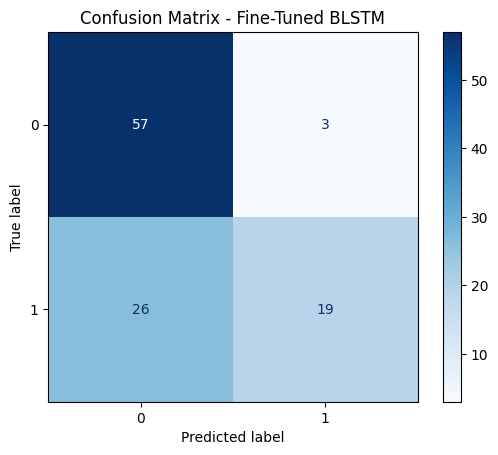

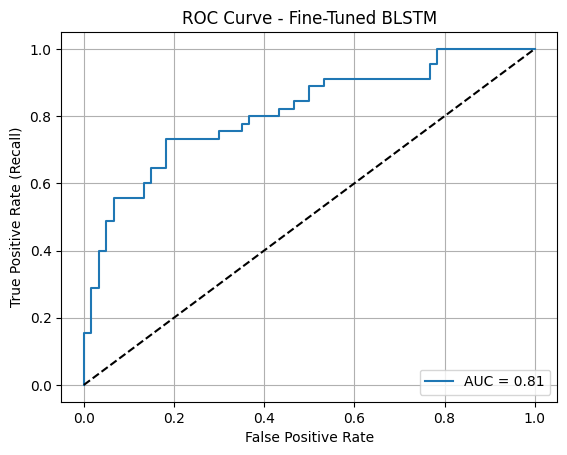

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Reshape input
X_finetune = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)
y_finetune = y_resampled

# Step 2: Load previously trained BLSTM model
model = load_model("bilstm_model_1.keras")

# Step 3: Compile with a smaller learning rate for fine-tuning
model.compile(optimizer=AdamW(learning_rate=0.0001, weight_decay=1e-4),  # 🔽 Lower LR for stable fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 4: Callbacks
callbacks = [
    EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

# Step 5: Train the model further
model.fit(
    X_finetune, y_finetune,
    epochs=100,
    batch_size=4,
    verbose=1,
    callbacks=callbacks
)

# Step 6: Evaluate
y_pred_proba = model.predict(X_finetune).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Step 7: Metrics
cm = confusion_matrix(y_finetune, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_finetune, y_pred_proba)

print("\n=== Fine-Tuned Model Evaluation ===")
print(classification_report(y_finetune, y_pred))
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"AUC Score : {auc:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Fine-Tuned BLSTM")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_finetune, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Fine-Tuned BLSTM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [28]:
model_path = 'bilstm_model_best.keras'
model.save(model_path)

In [41]:
model.save_weights("blstm_weights_best.weights.h5")


📊 Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.71      0.93      0.81        60
           1       0.85      0.49      0.62        45

    accuracy                           0.74       105
   macro avg       0.78      0.71      0.71       105
weighted avg       0.77      0.74      0.73       105

Sensitivity (Recall): 0.4889
Specificity          : 0.9333
AUC Score            : 0.7604


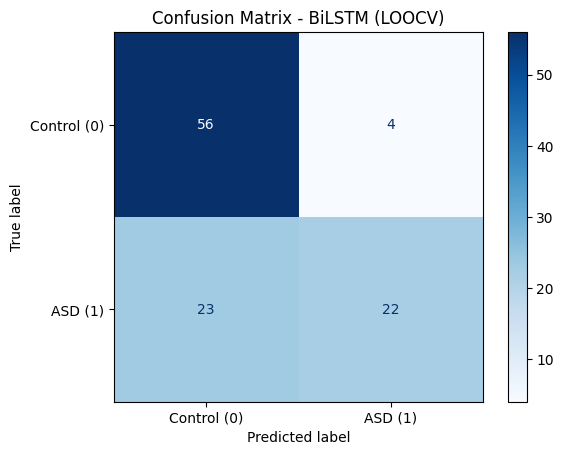

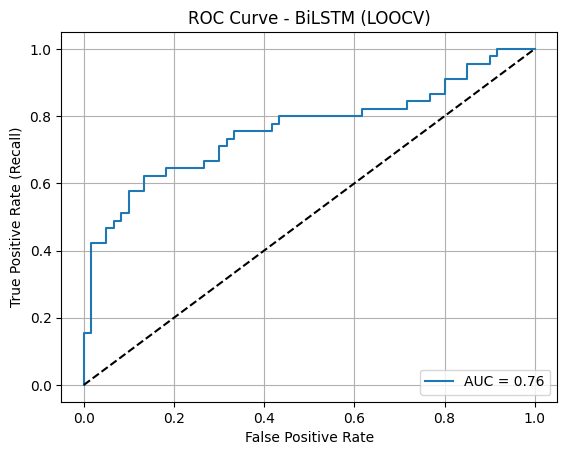

In [29]:
import os
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ========== 1. Set all random seeds ==========
def set_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds(42)

# ========== 2. Prepare data ==========
# Assume X_resampled and y_resampled are already available
X_lstm = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)
y_lstm = y_resampled

# ========== 3. Load the best model ==========
model = load_model("bilstm_model_best.keras")

# ========== 4. Run LOOCV ==========
loo = LeaveOneOut()
y_true, y_pred, y_proba = [], [], []

for train_idx, test_idx in loo.split(X_lstm):
    X_test = X_lstm[test_idx]
    y_test = y_lstm[test_idx]

    # Predict
    prob = model.predict(X_test, verbose=0)
    pred = (prob > 0.5).astype(int)

    y_true.append(y_test[0])
    y_pred.append(pred[0][0])
    y_proba.append(prob[0][0])

# ========== 5. Evaluation ==========
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_proba)

# ========== 6. Print Metrics ==========
print("\n📊 Classification Report (LOOCV):")
print(classification_report(y_true, y_pred))
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"AUC Score            : {auc:.4f}")

# ========== 7. Confusion Matrix ==========
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control (0)", "ASD (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - BiLSTM (LOOCV)")
plt.show()

# ========== 8. ROC Curve ==========
fpr, tpr, _ = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - BiLSTM (LOOCV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# GRU

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, roc_curve, classification_report
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout
#from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.random import set_seed
from tensorflow.keras.optimizers import Adam

# Set seed for reproducibility
set_seed(42)

# Step 1: Prepare GRU-compatible input
X_gru = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)
y_gru = y_resampled

# Step 2: Setup LOOCV
loo = LeaveOneOut()
y_true, y_pred, y_proba = [], [], []

print("\n=== Bidirectional GRU (LOOCV) ===")

for train_idx, test_idx in loo.split(X_gru):
    X_train, X_test = X_gru[train_idx], X_gru[test_idx]
    y_train, y_test = y_gru[train_idx], y_gru[test_idx]

    # Step 3: Build Bidirectional GRU model
    model = Sequential()
    model.add(Bidirectional(GRU(32, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    #optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-4)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    # model.compile(
    #     optimizer=optimizer,
    #     loss='binary_crossentropy',
    #     metrics=['accuracy']
    # )

    # Callbacks
    # lr_scheduler = ReduceLROnPlateau(
    #     monitor='loss',
    #     factor=0.5,
    #     patience=5,
    #     min_lr=1e-6,
    #     verbose=1
    # )

    #early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    # Step 4: Train the model
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=4,
        verbose=0,
        #callbacks=[lr_scheduler, early_stopping]
        callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
        
    )

    # Step 5: Predict
    prob = model.predict(X_test, verbose=0)
    pred = (prob > 0.5).astype(int)

    y_true.append(y_test[0])
    y_pred.append(pred[0][0])
    y_proba.append(prob[0][0])

# Step 6: Evaluation
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_proba)

# Print Report
print(classification_report(y_true, y_pred))
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"AUC Score: {auc:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Bidirectional GRU (LOOCV)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Bidirectional GRU (LOOCV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
